In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [5]:
df = pd.read_csv("C:/Users/keerthana/Downloads/educationaldata.csv")

print("First 5 rows:")
df.head()

First 5 rows:


,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [7]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

Dataset Shape: (480, 17)

Column Names:
Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  48

In [9]:
df.isnull().sum()

gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

In [11]:
# remove duplicate rows
df = df.drop_duplicates()

# fill missing numeric values with mean
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# fill categorical values with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum()

C:\Users\keerthana\AppData\Local\Temp\ipykernel_32952\1052374693.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

In [13]:
df.describe()
df.mean(numeric_only=True)
df.median(numeric_only=True)

raisedhands          50.0
VisITedResources     65.0
AnnouncementsView    33.0
Discussion           39.5
dtype: float64

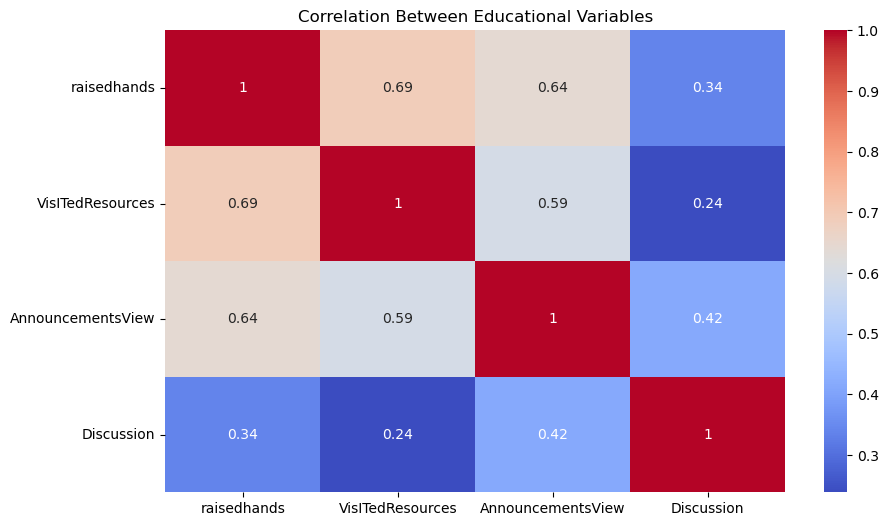

In [15]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Educational Variables")
plt.show()

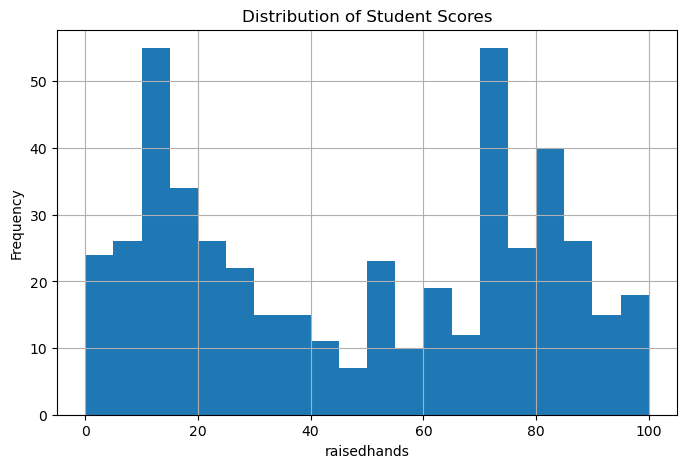

In [17]:
plt.figure(figsize=(8,5))

df[numeric_cols[0]].hist(bins=20)

plt.title("Distribution of Student Scores")
plt.xlabel(numeric_cols[0])
plt.ylabel("Frequency")

plt.show()

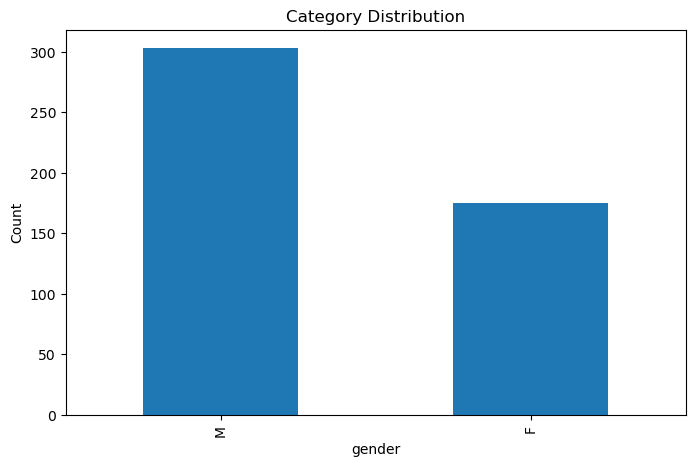

In [19]:
if len(categorical_cols) > 0:

    plt.figure(figsize=(8,5))

    df[categorical_cols[0]].value_counts().plot(kind='bar')

    plt.title("Category Distribution")
    plt.xlabel(categorical_cols[0])
    plt.ylabel("Count")

    plt.show()

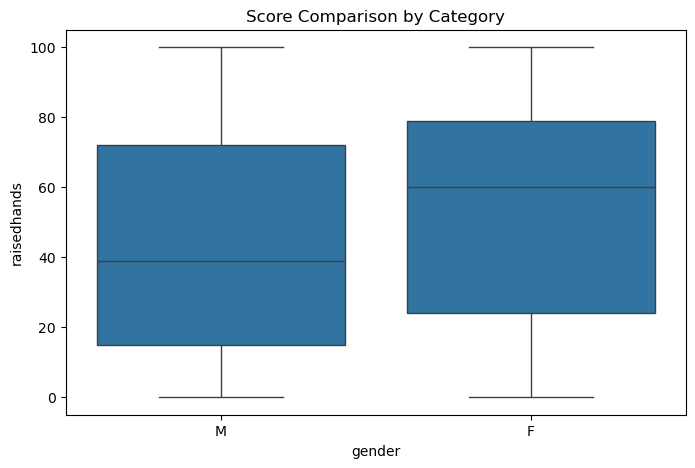

In [21]:
if len(categorical_cols) > 0 and len(numeric_cols) > 0:

    plt.figure(figsize=(8,5))

    sns.boxplot(x=df[categorical_cols[0]], y=df[numeric_cols[0]])

    plt.title("Score Comparison by Category")

    plt.show()

In [27]:
if 'study_hours' in df.columns and 'score' in df.columns:

    plt.figure(figsize=(8,5))

    sns.scatterplot(x='study_hours', y='score', data=df)

    plt.title("Study Hours vs Student Score")

    plt.show()

In [25]:
print("===== EDUCATIONAL DATA INSIGHTS =====")

print("Average Score:", df[numeric_cols[0]].mean())

print("Median Score:", df[numeric_cols[0]].median())

print("\nTop Correlations:")
print(corr.unstack().sort_values(ascending=False)[1:6])

if len(categorical_cols) > 0:
    print("\nMost common category:", df[categorical_cols[0]].value_counts().idxmax())

===== EDUCATIONAL DATA INSIGHTS =====
Average Score: 46.88702928870293
Median Score: 50.0

Top Correlations:
VisITedResources   VisITedResources     1.000000
AnnouncementsView  AnnouncementsView    1.000000
Discussion         Discussion           1.000000
raisedhands        VisITedResources     0.690635
VisITedResources   raisedhands          0.690635
dtype: float64

Most common category: M


In [29]:
df.to_csv("cleaned_educational_data.csv", index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully
